# Pretrained baselines with SAM — ResNet18, ViT‑B/16
- Fine‑tuning + SAM (ρ≈0.05), LLRD for ViT head, recall‑first evaluation.

In [2]:
# Clean imports + path setup
import sys
from pathlib import Path
import warnings

# tqdm: prefer notebook widgets, fallback to text
try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)

# Resolve project root (directory containing `src/`)
proj_root = Path.cwd()
for _ in range(5):
    if (proj_root / "src").exists():
        break
    proj_root = proj_root.parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))
print("sys.path[0] =", sys.path[0])

# Weights path
weights_path = proj_root / "notebooks" / "weights" / "ViT-B_16.npz"
print("weights:", weights_path)

# Project imports
from src import (
    DataCfg, TrainCfg, build_dataloaders, get_device, set_seed,
    build_custom_cnn, build_resnet18, build_vit_scratch, build_vit_pretrained,
    train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots,
    add_result, result_registry
)

import numpy as np, torch, time
set_seed(42)
DEVICE = get_device(); DEVICE


sys.path[0] = /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project
weights: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project/notebooks/weights/ViT-B_16.npz


device(type='mps')

In [3]:
# === Paths/config ===
DATASET_DIR = Path("../Data/chest_xray")  # <--- edit if needed

# Use the SAME split settings as scratch for fairness
data_cfg = DataCfg(
    dataset_dir=DATASET_DIR,
    image_size=224,
    batch_size=32,
    num_workers=0,             # use 0 if you're on Windows/limited env; 2+ is fine otherwise
    pin_memory=True,
    use_stratified_val=True,
    val_ratio=0.20,            # keep consistent across notebooks
    gray_to_rgb=True,          # convert grayscale to 3-ch to match pretrained weights
    compute_norm_stats=False,  # use ImageNet mean/std to match pretrained models
    balance_sampler=True
)

# Pretrained + SAM fine-tune defaults
pretrain_sam_cfg = TrainCfg(
    epochs=20, patience=5, monitor="va_auroc",
    base_lr=1e-4, weight_decay=1e-4,      # conservative finetune with SAM
    clip_grad_norm=1.0, use_amp=False,    # set True if your setup supports AMP
    use_sam=True, sam_rho=0.05,           # default rho here; ViT will override to 0.20
    use_cosine=True, warmup_epochs=2, min_lr_mult=0.05,
    target_recall=0.95,
    llrd=True, head_lr_mult=10.0,         # faster classifier head (esp. ViT)
    vit_npz_path=weights_path
)

train_loader, val_loader, test_loader, info = build_dataloaders(data_cfg, DEVICE)
print("Classes:", info["classes"])
print("Lens:", info["n_train"], info["n_val"], info["n_test"])
print("Train counts:", info["train_counts"])

# Imbalance handling: with balance_sampler=True, avoid class_weights to prevent double-weighting
class_weights = None


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4185 1047 624
Train counts: [1079, 3106]


[ResNet18-pretrained+SAM] epoch 01/20  tr_loss=0.6414  val_loss=0.6024  val_acc=0.6886  val_f1=0.7627  val_auroc=0.7845  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 02/20  tr_loss=0.5901  val_loss=0.5628  val_acc=0.7373  val_f1=0.7946  val_auroc=0.8841  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 03/20  tr_loss=0.5326  val_loss=0.5072  val_acc=0.7908  val_f1=0.8393  val_auroc=0.9324  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 04/20  tr_loss=0.4847  val_loss=0.4679  val_acc=0.8252  val_f1=0.8690  val_auroc=0.9342  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 05/20  tr_loss=0.4469  val_loss=0.4204  val_acc=0.8329  val_f1=0.8754  val_auroc=0.9523  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 06/20  tr_loss=0.4274  val_loss=0.3964  val_acc=0.8500  val_f1=0.8898  val_auroc=0.9530  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 07/20  tr_loss=0.4075  val_loss=0.3639  val_acc=0.8634  val_f1=0.9003  val_auroc=0.9606  (no_improve=0)
[ResNet18-pretrained+SAM] epoch 08/20  tr_loss=0

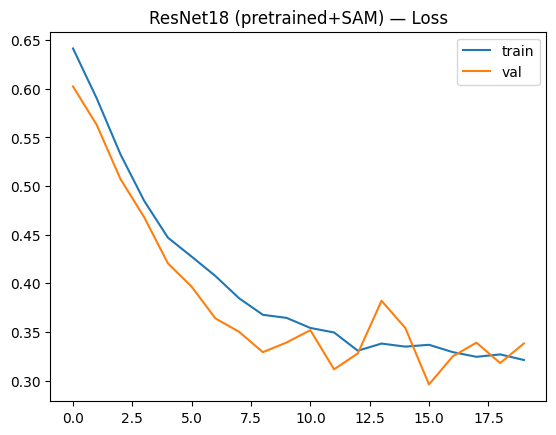

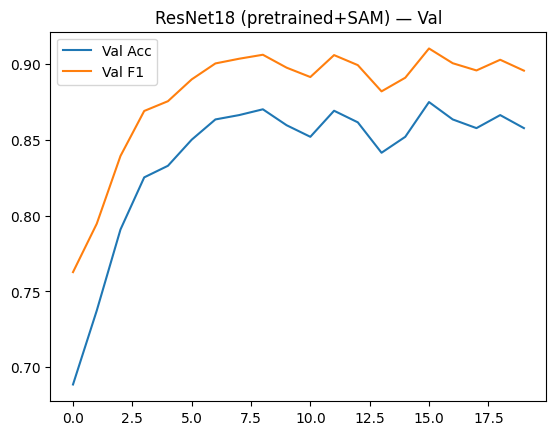

[ResNet18-pretrained+SAM @0.5] {'acc': 0.8429, 'precision': 0.8763, 'recall': 0.8718, 'f1': 0.874, 'auroc': 0.9073, 'thr': 0.5}
[ResNet18-pretrained+SAM @Rec] {'acc': 0.7821, 'precision': 0.751, 'recall': 0.9744, 'f1': 0.8482, 'auroc': 0.9073, 'thr': 0.1545}


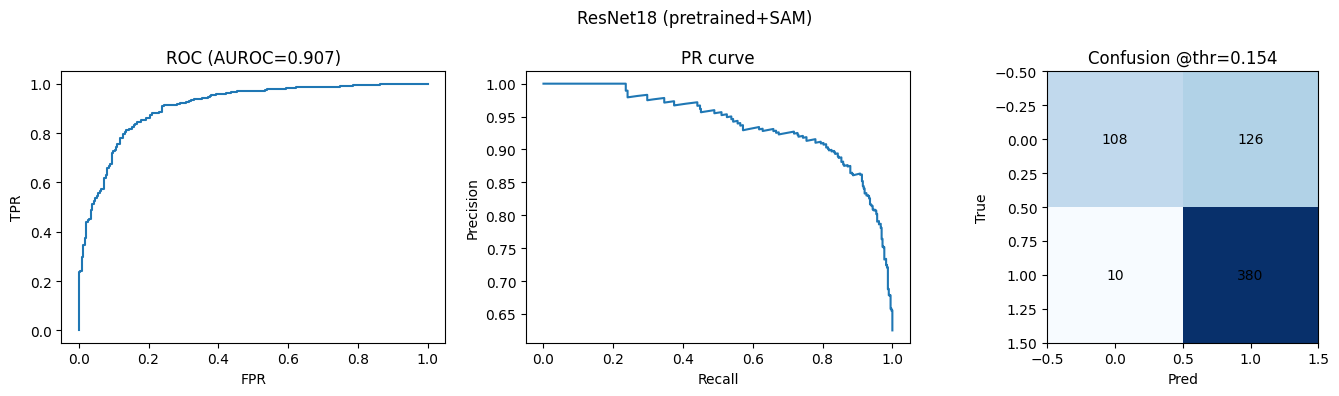

{'summary@0.5': {'acc': 0.842948717948718,
  'precision': 0.8762886597938144,
  'recall': 0.8717948717948718,
  'f1': 0.8740359897172236,
  'auroc': 0.9073197457812843,
  'thr': 0.5},
 'summary@recall': {'acc': 0.782051282051282,
  'precision': 0.7509881422924901,
  'recall': 0.9743589743589743,
  'f1': 0.8482142857142857,
  'auroc': 0.9073197457812843,
  'thr': 0.1545},
 'threshold': 0.1545,
 'time_sec': 1921.586007118225,
 'params': 11177538}

In [4]:
cfg = pretrain_sam_cfg

rn = build_resnet18(in_chans=3, num_classes=2, pretrained=True, conv_stem=False)

t0 = time.time()
rn_tr, rn_hist, rn_time = train_model(
    rn, train_loader, val_loader, DEVICE, arch="resnet18",
    epochs=cfg.epochs,
    base_lr=cfg.base_lr, weight_decay=cfg.weight_decay, label_smoothing=0.0,
    use_sam=True, sam_rho=0.05,                        # small rho for CNNs
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="ResNet18-pretrained+SAM"
)
rn_time = time.time() - t0

plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18 (pretrained+SAM) — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18 (pretrained+SAM) — Val")

va = evaluate(rn_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(rn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-pretrained+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-pretrained+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (pretrained+SAM)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (pretrained+SAM)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


In [ ]:
try:
    vit = build_vit_pretrained(
        num_classes=2, model_name="vit_base_patch16_224",
        pretrained=True, npz_path=pretrain_sam_cfg.vit_npz_path
    )
except Exception as e:
    print("ViT‑B/16 pretrained unavailable (no timm and no .npz). Skipping ViT cell.")
    vit = None

if vit is not None:
    t0 = time.time()
    vit_tr, vit_hist, vit_time = train_model(
        vit, train_loader, val_loader, DEVICE, arch="vit",
        epochs=pretrain_sam_cfg.epochs,
        base_lr=pretrain_sam_cfg.base_lr, weight_decay=pretrain_sam_cfg.weight_decay, label_smoothing=0.0,
        use_sam=True, sam_rho=0.20,  # larger rho for ViT-B/16 (per Table 11)
        use_cosine=pretrain_sam_cfg.use_cosine, warmup_epochs=pretrain_sam_cfg.warmup_epochs, min_lr_mult=pretrain_sam_cfg.min_lr_mult,
        monitor=pretrain_sam_cfg.monitor, patience=pretrain_sam_cfg.patience, clip_grad_norm=pretrain_sam_cfg.clip_grad_norm,
        class_weights=class_weights, llrd=pretrain_sam_cfg.llrd, head_lr_mult=pretrain_sam_cfg.head_lr_mult, use_amp=pretrain_sam_cfg.use_amp,
        tag="ViT-B/16-pretrained+SAM"
    )
    vit_time = time.time() - t0

    plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT‑B/16 (pretrained+SAM) — Loss")
    plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT‑B/16 (pretrained+SAM) — Val")

    va = evaluate(vit_tr, val_loader, DEVICE)
    thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], pretrain_sam_cfg.target_recall)
    te = evaluate(vit_tr, test_loader, DEVICE)
    sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
    sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
    print("[ViT-B/16-pretrained+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
    print("[ViT-B/16-pretrained+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
    diag_plots("ViT‑B/16 (pretrained+SAM)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
    add_result("ViT‑B/16 (pretrained+SAM)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


[ViT-B/16-pretrained+SAM] epoch 01/20  tr_loss=0.5755  val_loss=0.6003  val_acc=0.6944  val_f1=0.7415  val_auroc=0.9633  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 02/20  tr_loss=0.4448  val_loss=0.4197  val_acc=0.8281  val_f1=0.8696  val_auroc=0.9683  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 03/20  tr_loss=0.4244  val_loss=0.3943  val_acc=0.8214  val_f1=0.8636  val_auroc=0.9746  (no_improve=0)
[ViT-B/16-pretrained+SAM] epoch 04/20  tr_loss=0.3836  val_loss=0.4668  val_acc=0.7861  val_f1=0.8321  val_auroc=0.9728  (no_improve=1)
[ViT-B/16-pretrained+SAM] epoch 05/20  tr_loss=0.3710  val_loss=0.2613  val_acc=0.8978  val_f1=0.9282  val_auroc=0.9689  (no_improve=2)
[ViT-B/16-pretrained+SAM] epoch 06/20  tr_loss=0.3451  val_loss=0.3997  val_acc=0.8309  val_f1=0.8722  val_auroc=0.9746  (no_improve=0)


In [ ]:
# === Final comparison tables across all models in this notebook ===
# Builds two tables:
#   (A) Metrics at the threshold that achieves Recall >= 0.95 (from summary@recall)
#   (B) Metrics at fixed threshold = 0.5 (from summary@0.5)
# Requires: from src import result_registry ; each model added via add_result(name, ...)

import math, pandas as pd
from src import result_registry

TARGET_RECALL = 0.95  # what "recall >= 95%" means

if not result_registry:
    raise RuntimeError("result_registry is empty. Make sure you called add_result(...) after each model.")

def _extract_row(model_name: str, rec: dict, which: str):
    """
    which: 'summary@recall' or 'summary@0.5'
    Returns a flat row with common columns.
    """
    s = rec.get(which, {}) or {}
    # Prefer the per-summary 'thr' if present; else fall back to the top-level 'threshold'
    thr = s.get("thr", rec.get("threshold", float("nan")))
    row = {
        "model": model_name,
        "threshold": float(thr) if thr is not None and not isinstance(thr, str) else float("nan"),
        "acc": float(s.get("acc", float("nan"))),
        "precision": float(s.get("precision", float("nan"))),
        "recall": float(s.get("recall", float("nan"))),
        "f1": float(s.get("f1", float("nan"))),
        "auroc": float(s.get("auroc", float("nan"))),
        "params": rec.get("params", None),
        "time_sec": rec.get("time_sec", None),
    }
    return row

# Build both tables from the registry
rows_recall = []
rows_thr05 = []
for name, rec in result_registry.items():
    rows_recall.append(_extract_row(name, rec, "summary@recall"))
    rows_thr05.append(_extract_row(name, rec, "summary@0.5"))

df_recall = pd.DataFrame(rows_recall)
df_thr05  = pd.DataFrame(rows_thr05)

# Add convenience columns and formatting
def _format(df: pd.DataFrame, check_target=False) -> pd.DataFrame:
    df = df.copy()
    # Params in millions; training time in minutes
    if "params" in df:
        df["params (M)"] = df["params"].apply(lambda x: round(x/1e6, 2) if pd.notna(x) else math.nan)
    if "time_sec" in df:
        df["time (min)"] = df["time_sec"].apply(lambda x: round(x/60.0, 1) if pd.notna(x) else math.nan)

    # Human-friendly rounding
    if "threshold" in df: df["threshold"] = df["threshold"].round(3)
    for c in ["acc","precision","recall","f1","auroc"]:
        if c in df:
            df[c] = (df[c] * 100.0).round(2)  # show as %
    # Optional flag: did this row meet the target recall?
    if check_target and "recall" in df:
        df["meets_target(≥95%)"] = df["recall"].apply(lambda r: (pd.notna(r) and r >= TARGET_RECALL*100.0))
    # Reorder columns
    cols = ["model","threshold","acc","precision","recall","f1","auroc","params (M)","time (min)"]
    cols = [c for c in cols if c in df.columns]
    return df[cols]

# Sort by AUROC (desc) as a stable default; change to 'f1' if you prefer
df_recall = df_recall.sort_values(by="auroc", ascending=False).reset_index(drop=True)
df_thr05  = df_thr05.sort_values(by="auroc", ascending=False).reset_index(drop=True)

df_recall = _format(df_recall, check_target=True)
df_thr05  = _format(df_thr05,  check_target=False)

# Display
print("=== Table A — Metrics at threshold chosen to reach Recall ≥ 95% ===")
display(df_recall.style.format({
    "threshold": "{:.3f}",
    "acc": "{:.2f}%", "precision": "{:.2f}%", "recall": "{:.2f}%", "f1": "{:.2f}%", "auroc": "{:.2f}%",
    "params (M)": "{:.2f}", "time (min)": "{:.1f}"
}).set_properties(**{"text-align": "center"}))

print("\n=== Table B — Metrics at fixed threshold = 0.50 ===")
display(df_thr05.style.format({
    "threshold": "{:.3f}",
    "acc": "{:.2f}%", "precision": "{:.2f}%", "recall": "{:.2f}%", "f1": "{:.2f}%", "auroc": "{:.2f}%",
    "params (M)": "{:.2f}", "time (min)": "{:.1f}"
}).set_properties(**{"text-align": "center"}))

# (Optional) Save to CSV alongside the notebook
# df_recall.to_csv("results_table_recall>=95.csv", index=False)
# df_thr05.to_csv("results_table_thr=0.5.csv", index=False)


ModuleNotFoundError: No module named 'src'